### Table content:
* [Introduction](#Introduction)
* [Data pipeline](#DATA-VISUALIZATION)
* [CNN Model](#BUILD-A-SIMPLE-CNN-MODEL)
* [Model and Loss function](#Model-and-Loss-function)
    * [VGG19](#VGG19)
    * [Loss function](#Loss-function)
    * [Generator and Discriminator model](#Generator-and-Discriminator-model)
* [Custom SRGAN training](#Custom-training)
* [Model training](#Training)

## Introduction

[SRGAN: Photo-Realistic Single Image Super-Resolution Using a Generative Adversarial Network](https://arxiv.org/pdf/1609.04802.pdf)

SRGAN, introduced in 2017 by Christian Ledig et al., represents a groundbreaking approach to single-image super-resolution using Generative Adversarial Networks (GANs). By use the adversarial training, SRGAN pushes the boundaries of image enhancement by generating high-resolution images with remarkable fidelity and realism. This innovative model outperforms traditional interpolation methods and earlier deep learning approaches by producing visually compelling results with finer details and sharper edges. Its impact spans various fields, from photography to medical imaging, and beyond.

In this work, we focus on reimplement and optimizing SRGAN for multi-GPU and TPU systems to accelerate training and unleash its full potential in high-performance computing environments and testing on medical image.

In [3]:
import os
import time
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow import keras
# tf.keras.mixed_precision.set_global_policy('mixed_float16')
# tf.keras.backend.set_floatx('float16')

In [4]:
# initialize tpu or use Mirrored Strategy for multi-GPU
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver() # TPU detection
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("on TPU")
except:
    print("not on TPU")
    strategy = tf.distribute.MirroredStrategy()

print("REPLICAS: ", strategy.num_replicas_in_sync)

INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


2024-03-21 10:23:58.681665: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-03-21 10:23:58.681780: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-03-21 10:23:58.681849: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-03-21 10:23:58.681936: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-03-21 10:23:58.682009: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-03-21 10:23:58.682199: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2024-03-21 10:23:58.682294: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this 

INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [5]:
# Some config
LR_IMG_SIZE = (96,96)
HR_IMG_SIZE = (384,384)
CHANNELS = 1 # Change channel to 3 if you dataset image not in gray scale.
BATCH_SIZE_PER_REPLICA = 24
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

## Create dataloader

In [6]:
def load_images(hr_path, channels = 3):
    hr_image = tf.io.read_file(hr_path)
    hr_image = tf.io.decode_jpeg(hr_image, channels = channels)
    if channels == 1:
        hr_image = tf.image.grayscale_to_rgb(hr_image)
    return hr_image

def random_flip(hr_image):
    if tf.random.uniform(()) > 0.5:
        hr_image = tf.image.flip_left_right(hr_image)
    return hr_image

def normalize_image(hr_image):
    hr_image = tf.cast(hr_image, tf.float32)

    hr_image = tf.image.random_crop(hr_image, size = (*HR_IMG_SIZE,3))
#     hr_image = tf.image.resize(hr_image,[*HR_IMG_SIZE], method=tf.image.ResizeMethod.BICUBIC)
    lr_image = tf.image.resize(hr_image,[*LR_IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    lr_image = (lr_image - 127.5) / 127.5
    hr_image = (hr_image - 127.5) / 127.5
    return lr_image, hr_image

def rescale_image(hr_image):
    hr_image = tf.image.convert_image_dtype(hr_image, tf.float32) # Rescale to [0, 1]
    # hr_image = tf.image.random_crop(hr_image, size = (*HR_IMG_SIZE, 3))
    hr_image = tf.image.resize(hr_image,[*HR_IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    lr_image = tf.image.resize(hr_image,[*LR_IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    return lr_image, hr_image

@tf.function
def create_train_dataset(img_filenames, img_channels = CHANNELS, is_normalize = False, batch_size = 12, cache = False):
    dataset = tf.data.Dataset.from_tensor_slices(img_filenames)
#     dataset = tf.data.TFRecordDataset(dataset)
    options = tf.data.Options()
    options.deterministic = False
    dataset = dataset.with_options(options)
    dataset = dataset.map(lambda x: load_images(x, channels = img_channels), num_parallel_calls=tf.data.experimental.AUTOTUNE)

    dataset = dataset.map(random_flip, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    if is_normalize:
        print('Dataset images will normalize to [-1, 1]')
        dataset = dataset.map(normalize_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    else:
        print('Dataset images will rescale to [0, 1]')
        dataset = dataset.map(rescale_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    dataset = dataset.shuffle(buffer_size=dataset.cardinality()).batch(batch_size, drop_remainder=True)
    if cache:
        return dataset.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    else:
        return dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

In [7]:
def val_image(hr_image):
    hr_image = tf.cast(hr_image, tf.float32)  # Convert to float32
    # hr_image = tf.image.convert_image_dtype(hr_image, tf.float32)
    hr_image = tf.image.resize(hr_image,[*HR_IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    lr_image = tf.image.resize(hr_image,[*LR_IMG_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    lr_image = (lr_image - 127.5) / 127.5
    hr_image = (hr_image - 127.5) / 127.5
    return lr_image, hr_image

def create_val_dataset(hr_image, img_channels = CHANNELS, batch_size = 1):
    val_dataset = tf.data.Dataset.from_tensor_slices(hr_image)
    options = tf.data.Options()
    options.deterministic = False
    val_dataset = val_dataset.with_options(options)
    val_dataset = val_dataset.map(lambda x: load_images(x, channels = img_channels), num_parallel_calls=tf.data.experimental.AUTOTUNE)
    val_dataset = val_dataset.map(val_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    val_batch_size = batch_size * strategy.num_replicas_in_sync
    val_dataset = val_dataset.batch(val_batch_size, drop_remainder=True).cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return val_dataset

### Dataset
I use [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) dataset.

There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).

In [25]:
hr_train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
hr_val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

hr_train_filenames = []
for dirname, _, filenames in os.walk(hr_train_dir):
    for filename in filenames:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            hr_train_filenames.append(os.path.join(dirname, filename))
print(len(hr_train_filenames))

hr_val_filenames = []
for dirname, _, filenames in os.walk(hr_val_dir):
    for filename in filenames:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            hr_val_filenames.append(os.path.join(dirname, filename))
print(len(hr_val_filenames))

5216
624


In [24]:
# Check images have height or width < 384, and images not in gray.
def check_err(filelist):
    shape_err = []
    channel_err  = []
    for i in filelist:
        hr_image = tf.io.read_file(i)
        hr_image = tf.io.decode_jpeg(hr_image, channels = 0)
        if hr_image.shape[0]<384 or hr_image.shape[1]<384:
            shape_err.append(i)
        if hr_image.shape[2] != 1:
            channel_err.append(i)
    print("Shape error: ", len(shape_err))
    print("Channel error: ", len(channel_err))
    return shape_err, channel_err

In [26]:
for i in check_err(hr_train_filenames)[0]:
    hr_train_filenames.remove(i)
for i in check_err(hr_val_filenames)[0]:
    hr_val_filenames.remove(i)

Shape error:  103
Channel error:  283
Shape error:  2
Channel error:  0


In [27]:
print(len(hr_train_filenames))
print(len(hr_val_filenames))

5113
622


In [12]:
with strategy.scope():
    dataset = create_train_dataset(hr_train_filenames, img_channels = CHANNELS, is_normalize = True, batch_size = GLOBAL_BATCH_SIZE, cache = True)
    val_dataset = create_val_dataset(hr_val_filenames, img_channels = CHANNELS, batch_size = 1)
    options = tf.distribute.InputOptions(experimental_fetch_to_device=False)
    dataset = strategy.experimental_distribute_dataset(dataset, options)
#     val_dataset = strategy.experimental_distribute_dataset(val_dataset, options)
    # dataset = strategy.distribute_datasets_from_function(
    #     lambda _: create_train_dataset(hr_filenames, is_normalize = True, batch_size = GLOBAL_BATCH_SIZE, cache = True))
    # val_dataset = strategy.distribute_datasets_from_function(
    #     lambda _: create_val_dataset(hr_val_filenames, batch_size = 12))

Dataset images will normalize to [-1, 1]


In [ ]:
train_sample = next(iter(dataset))
img = train_sample[0].values
mask = train_sample[1].values

fig, ax = plt.subplots(5,2, figsize = (12,30))
ax = ax.flatten()
for i in range(5):
    ax[2*i].imshow(np.round((img[0][i]+1)*127.5).astype(np.uint8))
    ax[2*i].set_yticks([])
    ax[2*i+1].imshow(np.round((mask[0][i]+1)*127.5).astype(np.uint8))
    ax[2*i+1].set_yticks([])
plt.subplots_adjust(wspace=0.05, hspace=0.05)
fig.suptitle('Train/Label', y = 0.89)
plt.show()

In [ ]:
val_samples = list(iter(val_dataset.take(5)))
fig, ax = plt.subplots(5,2, figsize = (15,36))
ax = ax.flatten()
for i in range(5):
    ax[2*i].imshow(np.round((((val_samples[i][0][0])+1)*127.5)).astype(np.uint8))
    ax[2*i].set_yticks([])
    ax[2*i+1].imshow(np.round((((val_samples[i][1][0])+1)*127.5)).astype(np.uint8))
    ax[2*i+1].set_yticks([])
plt.subplots_adjust(wspace=0.01, hspace=0.05)
fig.suptitle('Val/Label', y = 0.89)
plt.show()

## Model and Loss function

### VGG19

In [13]:
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
with strategy.scope():
    layer_5_4 = 20
    vgg = VGG19(input_shape=(*HR_IMG_SIZE, 3), include_top=False)
    VGG = tf.keras.Model(vgg.input, vgg.layers[layer_5_4].output)
    VGG.trainable = False

### Loss function

In [14]:
@tf.function
def _adversarial_loss(d_model, loss_object, hr_fake):
    _, y_discrim_logits = d_model(hr_fake)
    return tf.reduce_mean(loss_object(y_discrim_logits, tf.ones_like(y_discrim_logits)))

@tf.function
def denormalize(x):
    return (x + 1) * 127.5

@tf.function
def gen_loss_fn(d_model, loss_fn1 = tf.keras.losses.BinaryCrossentropy(), loss_fn2 = tf.keras.losses.MeanSquaredError(), hr = None, hr_fake = None):
    feature_fake = VGG(preprocess_input(denormalize(hr_fake))) / 12.75
    feature_real = VGG(preprocess_input(denormalize(hr))) / 12.75
    g_gan_loss = 1e-3 * _adversarial_loss(d_model, loss_fn1, hr_fake) # adversarial loss
    mse_loss = loss_fn2(hr, hr_fake) # content loss
    vgg_loss = loss_fn2(feature_real, feature_fake) # content loss
    return mse_loss, g_gan_loss, vgg_loss

@tf.function
def disc_loss_fn(loss_object = tf.keras.losses.BinaryCrossentropy(), y_real_pred_logits = None, y_fake_pred_logits = None):
    loss_real = tf.reduce_mean(loss_object(tf.ones_like(y_real_pred_logits), y_real_pred_logits))
    loss_fake = tf.reduce_mean(loss_object(tf.zeros_like(y_fake_pred_logits), y_fake_pred_logits))
    return loss_real + loss_fake

@tf.function
def res2img(img):
    return tf.round(denormalize(img))

@tf.function
def compute_psnr(original_image, generated_image):
    psnr = tf.image.psnr(res2img(original_image), res2img(generated_image), max_val=255)
    return tf.math.reduce_mean(psnr, axis=None, keepdims=False, name=None)

@tf.function
def compute_ssim(original_image, generated_image):
    ssim = tf.image.ssim(res2img(original_image), res2img(generated_image), max_val=255)
    return tf.math.reduce_mean(ssim, axis=None, keepdims=False, name=None)

class PSNR(tf.keras.metrics.Metric):

    def __init__(self, name='psnr', **kwargs):
        super(PSNR, self).__init__(name=name, **kwargs)
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
        self.compute_psnr = compute_psnr

    def update_state(self, original_image, generated_image, sample_weight=None):

        psnr = self.compute_psnr(original_image, generated_image)
        self.total.assign_add(psnr)
        self.count.assign_add(1.0)

    @tf.function
    def result(self):
        if self.count != 0:
            return self.total / self.count
        else:
            return 0.0

    def reset_states(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

### Generator and Discriminator model

In [28]:
#Generator model
# @tf.keras.saving.register_keras_serializable()
class Generator(tf.keras.Model):
    def __init__(self, num_blocks = 16, **kwargs):
#         super(Generator, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same')
        # self.prelu = tf.keras.layers.PReLU(shared_axes=[1,2])
        self.relu = tf.keras.layers.ReLU()

#         self.residual_blocks = []
#         for _ in tf.range(num_blocks):
#             self.residual_blocks.append(ResidualBlock())
#         self.residual_blocks = tf.keras.Sequential(self.residual_blocks)
        self.residual_blocks = tf.keras.Sequential([
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock(),
            ResidualBlock()
        ])
        self.conv2 = tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', bias_initializer = None)
        self.bn1 = tf.keras.layers.BatchNormalization(synchronized = True)

        self.conv3 = tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), strides=1, padding='same')
        self.subpixel1 = tf.keras.layers.Lambda(lambda x:tf.nn.depth_to_space(x, 2))
        # self.prelu1 = tf.keras.layers.PReLU(shared_axes=[1, 2])
        self.relu1 = tf.keras.layers.ReLU()

        self.conv4 = tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), strides=1, padding='same')
        self.subpixel2 = tf.keras.layers.Lambda(lambda x:tf.nn.depth_to_space(x, 2))
        # self.prelu2 = tf.keras.layers.PReLU(shared_axes=[1, 2])
        self.relu2 = tf.keras.layers.ReLU()

        self.conv5 = tf.keras.layers.Conv2D(filters=3, kernel_size=(1,1), strides=1, padding='same',  activation='tanh')

        self.input_layer = tf.keras.layers.Input(shape=(*LR_IMG_SIZE,3), name="input_layer")

        input_shape = self.input_layer
        outputs_shape = self.call(input_shape)

        super(Generator, self).__init__(inputs=input_shape, outputs=outputs_shape, **kwargs)

    def call(self, x):
        x = self.conv1(x)
        # x = self.prelu(x)
        x = self.relu(x)
        temp = x

        x = self.residual_blocks(x)
        x = self.conv2(x)
        x = self.bn1(x)
        x = x + temp

        x = self.conv3(x)
        x = self.subpixel1(x)
        # x = self.prelu1(x)
        x = self.relu1(x)

        x = self.conv4(x)
        x = self.subpixel2(x)
        # x = self.prelu2(x)
        x = self.relu2(x)

        x = self.conv5(x)

        return x

    def get_config(self):
        config = super(Generator, self).get_config()
        return config

    def summary_model(self, input_shape):
        inputs = tf.keras.Input(shape=input_shape)
        outputs = self.call(inputs)
        tf.keras.Model(inputs=inputs, outputs=outputs).summary()

class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self):
        super(ResidualBlock, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')
        self.bn1 = tf.keras.layers.BatchNormalization(synchronized = True)
        # self.prelu = tf.keras.layers.PReLU(shared_axes=[1, 2])
        self.relu = tf.keras.layers.ReLU()
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')
        self.bn2 = tf.keras.layers.BatchNormalization(synchronized = True)

    def call(self, x):
        z = self.conv1(x)
        z = self.bn1(z)
        # z = self.prelu(z)
        z = self.relu(z)
        z = self.conv2(z)
        z = self.bn2(z)
        x = x + z
        return x

#Discriminator model
# @tf.keras.saving.register_keras_serializable()
class Discriminator(tf.keras.Model):
    def __init__(self, learning_rate=1e-4, **kwargs):
#         super(Discriminator, self).__init__()

        self.learning_rate = learning_rate

        self.conv1 = tf.keras.layers.Conv2D(kernel_size=3, filters=64, strides=1, padding='same')
        self.leaky1 = tf.keras.layers.LeakyReLU(alpha=0.2)

        self.convblock = tf.keras.Sequential([
                                    ConvolutionBlock(64,  3, 2),
                                    ConvolutionBlock(128, 3, 2),
                                    ConvolutionBlock(128, 3, 2),
                                    ConvolutionBlock(256, 3, 2),
                                    ConvolutionBlock(256, 3, 2),
                                    ConvolutionBlock(512, 3, 1),
                                    ConvolutionBlock(512, 3, 1),
                                    ])
#         self.convblock = tf.keras.Sequential(self.convblock)

        self.flatten = tf.keras.layers.Flatten()
        self.Dense1 = tf.keras.layers.Dense(256)
        self.leaky2 = tf.keras.layers.LeakyReLU(alpha=0.2)
        self.Dense2 = tf.keras.layers.Dense(1)
        self.sigmoid = tf.keras.layers.Activation('sigmoid')

        self.input_layer = tf.keras.layers.Input(shape=(*HR_IMG_SIZE, 3), name="input_layer")

        input_shape = self.input_layer
        outputs_shape = self.call(input_shape)

        super(Discriminator, self).__init__(inputs=input_shape, outputs=outputs_shape, **kwargs)

    def call(self, x):
        x = self.conv1(x)
        x = self.leaky1(x)

        x = self.convblock(x)

        x = self.flatten(x)
        x = self.Dense1(x)
        x = self.leaky2(x)
        logits = self.Dense2(x)
        n = self.sigmoid(logits)
        return n, logits

    def get_config(self):
        config = super(Discriminator, self).get_config()
        return config

    def summary_model(self, input_shape):
        inputs = tf.keras.Input(shape=input_shape)
        outputs = self.call(inputs)
        tf.keras.Model(inputs=inputs, outputs=outputs).summary()

class ConvolutionBlock(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, strides):
        super(ConvolutionBlock, self).__init__()
        self.conv = tf.keras.layers.Conv2D(filters=filters, kernel_size=kernel_size, strides=strides, padding='same')
        self.batch_norm = tf.keras.layers.BatchNormalization(synchronized=True)
        self.leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2)

    def call(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.leaky_relu(x)
        return x

In [31]:
tf.keras.backend.clear_session()
g_test = Generator()
g_test.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 96, 96,    │          0 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 96, 96,    │  1,189,888 │ re_lu[0][0]       │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 96, 96,    │     36,928 │ sequential[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 96, 96,    │    147,712 │ add[0][0]         │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 192, 192,  │          0 │ conv2d_34[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 192, 192,  │          0 │ lambda[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 192, 192,  │    147,712 │ re_lu_17[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 384, 384,  │          0 │ conv2d_35[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 384, 384,  │          0 │ lambda_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 384, 384,  │        195 │ re_lu_18[0][0]    │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,524,483 (5.82 MB)

 Trainable params: 1,520,259 (5.80 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [32]:
d_test = Discriminator()
d_test.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 384, 384, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 384, 384, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 12, 12, 512)    │     4,691,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    18,874,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,567,681 (89.90 MB)

 Trainable params: 23,563,969 (89.89 MB)

 Non-trainable params: 3,712 (14.50 KB)

## Custom training

In [22]:
with strategy.scope():
    g = Generator()
    d = Discriminator()

    g_optimizer = tf.keras.optimizers.Adam(1e-4)
    d_optimizer = tf.keras.optimizers.Adam(1e-4)

    generator_loss = gen_loss_fn
    discriminator_loss = disc_loss_fn
    loss_fn1 = tf.keras.losses.BinaryCrossentropy(from_logits=True, reduction=tf.keras.losses.Reduction.NONE)
    loss_fn2 = tf.keras.losses.MeanSquaredError()
    psnr_calc = compute_psnr
    ssim_calc = compute_ssim

    g_loss_metric = tf.keras.metrics.Mean(name='g_loss')
    mse_loss_metric = tf.keras.metrics.Mean(name='mse_loss')
    g_gan_loss_metric = tf.keras.metrics.Mean(name='g_gan_loss')
    vgg_loss_metric = tf.keras.metrics.Mean(name='vgg_loss')
    d_loss_metric = tf.keras.metrics.Mean(name='d_loss')
    psnr_metric = tf.keras.metrics.Mean(name='psnr')
    ssim_metric = tf.keras.metrics.Mean(name='ssim')
# steps_per_execution = 50

/usr/local/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [47]:
with strategy.scope():

    @tf.function
    def train_step(image):
        lr, hr = image
        print(hr.shape)
        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

            # Generator
            fake_hr = g(lr, training = True)
            mse_loss, g_gan_loss, vgg_loss = generator_loss(d, loss_fn1, loss_fn2, hr, fake_hr)
            g_loss = mse_loss + g_gan_loss + vgg_loss

            # Discriminator
            d_hr_pred, d_hr_pred_logits = d(hr)
            d_hr_fake_pred, d_hr_fake_pred_logits = d(fake_hr)
            d_loss = discriminator_loss(loss_fn1, d_hr_pred_logits, d_hr_fake_pred_logits)
        generator_gradients = gen_tape.gradient(g_loss, g.trainable_variables)
        discriminator_gradients = disc_tape.gradient(d_loss, d.trainable_variables)

        g_optimizer.apply_gradients(zip(generator_gradients, g.trainable_variables))
        d_optimizer.apply_gradients(zip(discriminator_gradients, d.trainable_variables))

        psnr = psnr_calc(hr, fake_hr)
        ssim = ssim_calc(hr, fake_hr)

        d_loss_metric.update_state(d_loss)
        g_loss_metric.update_state(g_loss)
        mse_loss_metric.update_state(mse_loss)
        g_gan_loss_metric.update_state(g_gan_loss)
        vgg_loss_metric.update_state(vgg_loss)
        psnr_metric.update_state(psnr)
        ssim_metric.update_state(ssim)

        return d_loss_metric.result(),\
                g_loss_metric.result(),\
                mse_loss_metric.result(),\
                g_gan_loss_metric.result(),\
                vgg_loss_metric.result(), psnr_metric.result(), ssim_metric.result()

    @tf.function
    def distributed_train_step(dataset_inputs):
        per_replica_losses = strategy.run(train_step, args=(dataset_inputs,))
        x = []
        for loss in per_replica_losses:
            x.append(strategy.reduce(tf.distribute.ReduceOp.MEAN, loss, axis=None))
        x = tf.stack(x)
        return x

    @tf.function
    def distributed_train_epoch(train_dist_dataset):
        loss = tf.constant(0.0, dtype=tf.float32, shape=(7,))
        num_batches = 0.0
        for x in train_dist_dataset:
            loss += distributed_train_step(x)
            num_batches += 1.0
        loss = loss / num_batches
        return loss

#     @tf.function
    def distributed_test_epoch(g_model, test_dist_dataset, img_convert = True):

        permanent_sample = next(iter(test_dist_dataset))

        val_dataset_shuffled = test_dist_dataset.shuffle(buffer_size=len(hr_val_filenames))

        random_samples = val_dataset_shuffled.take(2)

        fig, ax = plt.subplots(3,3, figsize=(12,12))
        if img_convert:
            ax[0,0].imshow(np.round((permanent_sample[0][0]+1)*127.5).astype('uint8'))
            ax[0,1].imshow(np.round(((g_model(tf.expand_dims(permanent_sample[0][0], axis = 0))[0] + 1) * 127.5).numpy()).astype('uint8'))
            ax[0,2].imshow(np.round((permanent_sample[1][0]+1)*127.5).astype('uint8'))
            ax[0,0].set_yticklabels([])
            ax[0,1].set_yticklabels([])
            ax[0,2].set_yticklabels([])

            for i, batch in enumerate(random_samples):
                lr_batch, hr_batch = batch
                ax[i+1,0].imshow(np.round(((lr_batch[0]+1)*127.5)).astype('uint8'))
                ax[i+1,1].imshow(np.round(((g_model(tf.expand_dims(lr_batch[0], axis = 0))[0] + 1) * 127.5).numpy()).astype('uint8'))
                ax[i+1,2].imshow(np.round(((hr_batch[0]+1)*127.5)).astype('uint8'))
                ax[i+1,0].set_yticklabels([])
                ax[i+1,1].set_yticklabels([])
                ax[i+1,2].set_yticklabels([])
        else:
            ax[0,0].imshow(permanent_sample[0][0])
            ax[0,1].imshow(g_model(permanent_sample[0])[0])
            ax[0,2].imshow(permanent_sample[1][0])

            for i, batch in enumerate(random_samples):
                lr_batch, hr_batch = batch
                ax[i+1,0].imshow(lr_batch[0])
                ax[i+1,1].imshow(((g_model(lr_batch)[0])))
                ax[i+1,2].imshow(hr_batch[0])
        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        plt.show()

        save_options = tf.saved_model.SaveOptions(experimental_io_device='/job:localhost')
        tf.saved_model.save(g,export_dir = '/kaggle/working/gen', options=save_options)
        tf.saved_model.save(d,export_dir = '/kaggle/working/disc', options=save_options)

## Training

/usr/local/lib/python3.10/site-packages/tensorflow/python/data/ops/dataset_ops.py:462: UserWarning: To make it possible to preserve tf.data options across serialization boundaries, their implementation has moved to be part of the TensorFlow graph. As a consequence, the options value is in general no longer known at graph construction time. Invoking this method in graph mode retains the legacy behavior of the original implementation, but note that the returned value might not reflect the actual value of the options.
  warnings.warn("To make it possible to preserve tf.data options across "


(None, 384, 384, 3)
Epoch:  1
ETA: 104.0s d_loss: 1.398872, g_loss: 0.080653, mse_loss: 0.056807, g_gan_loss: 0.001548, vgg_loss: 0.022298, psnr: 21.792446, ssim: 0.380606
Epoch:  2
ETA: 25.0s d_loss: 1.330276, g_loss: 0.059339, mse_loss: 0.036717, g_gan_loss: 0.001522, vgg_loss: 0.021101, psnr: 24.156239, ssim: 0.486335
Epoch:  3
ETA: 25.0s d_loss: 1.197914, g_loss: 0.049965, mse_loss: 0.027817, g_gan_loss: 0.001719, vgg_loss: 0.020429, psnr: 25.480228, ssim: 0.537529
Epoch:  4
ETA: 25.0s d_loss: 1.168583, g_loss: 0.044629, mse_loss: 0.022819, g_gan_loss: 0.001804, vgg_loss: 0.020006, psnr: 26.273918, ssim: 0.563080
Epoch:  5
ETA: 25.0s d_loss: 1.203133, g_loss: 0.040860, mse_loss: 0.019552, g_gan_loss: 0.001762, vgg_loss: 0.019546, psnr: 26.872623, ssim: 0.582913
Epoch:  6
ETA: 25.0s d_loss: 1.206565, g_loss: 0.037913, mse_loss: 0.017144, g_gan_loss: 0.001727, vgg_loss: 0.019042, psnr: 27.441193, ssim: 0.601968
Epoch:  7
ETA: 25.0s d_loss: 1.216800, g_loss: 0.035596, mse_loss: 0.0153

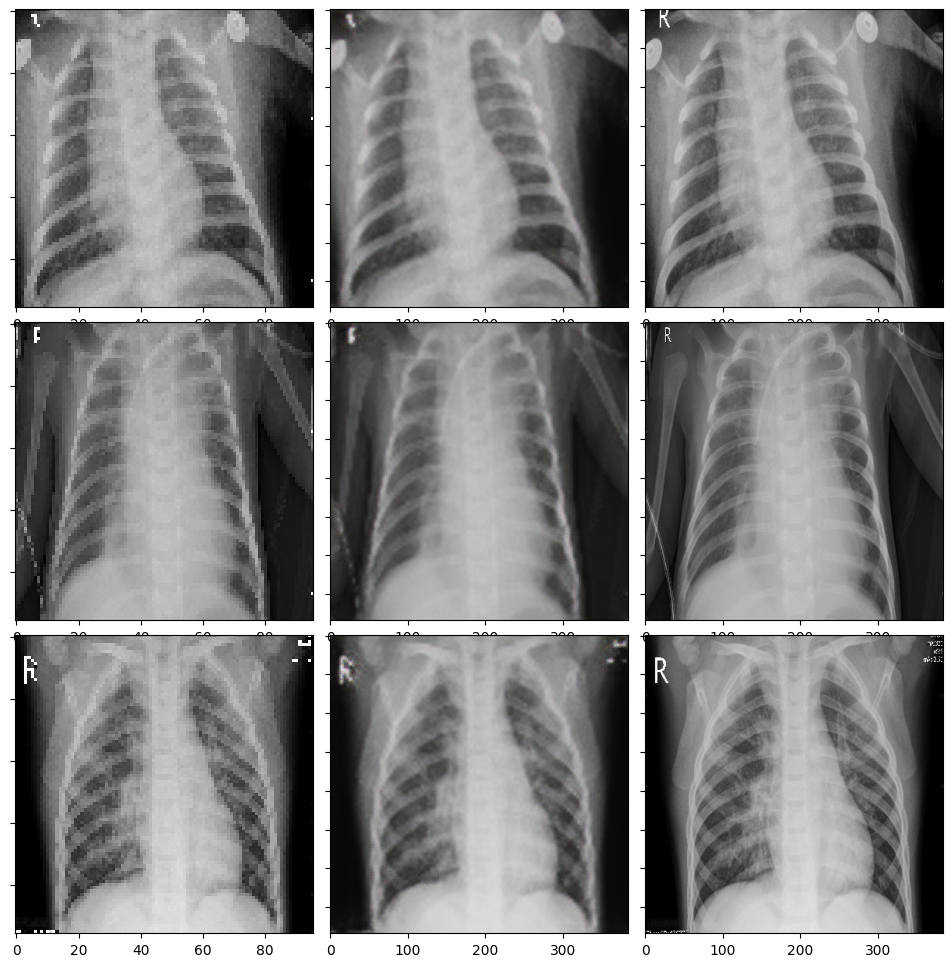

INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


Epoch:  21
ETA: 25.0s d_loss: 1.300926, g_loss: 0.021915, mse_loss: 0.006819, g_gan_loss: 0.001503, vgg_loss: 0.013593, psnr: 31.271748, ssim: 0.708087
Epoch:  22
ETA: 25.0s d_loss: 1.303770, g_loss: 0.021453, mse_loss: 0.006590, g_gan_loss: 0.001498, vgg_loss: 0.013366, psnr: 31.411421, ssim: 0.712048
Epoch:  23
ETA: 25.0s d_loss: 1.305631, g_loss: 0.021020, mse_loss: 0.006377, g_gan_loss: 0.001492, vgg_loss: 0.013151, psnr: 31.547081, ssim: 0.715967
Epoch:  24
ETA: 25.0s d_loss: 1.308125, g_loss: 0.020617, mse_loss: 0.006182, g_gan_loss: 0.001486, vgg_loss: 0.012949, psnr: 31.674112, ssim: 0.719624
Epoch:  25
ETA: 25.0s d_loss: 1.309450, g_loss: 0.020241, mse_loss: 0.006001, g_gan_loss: 0.001482, vgg_loss: 0.012758, psnr: 31.792927, ssim: 0.723008
Epoch:  26
ETA: 25.0s d_loss: 1.311737, g_loss: 0.019892, mse_loss: 0.005835, g_gan_loss: 0.001478, vgg_loss: 0.012579, psnr: 31.897615, ssim: 0.725906
Epoch:  27
ETA: 25.0s d_loss: 1.312788, g_loss: 0.019563, mse_loss: 0.005679, g_gan_loss

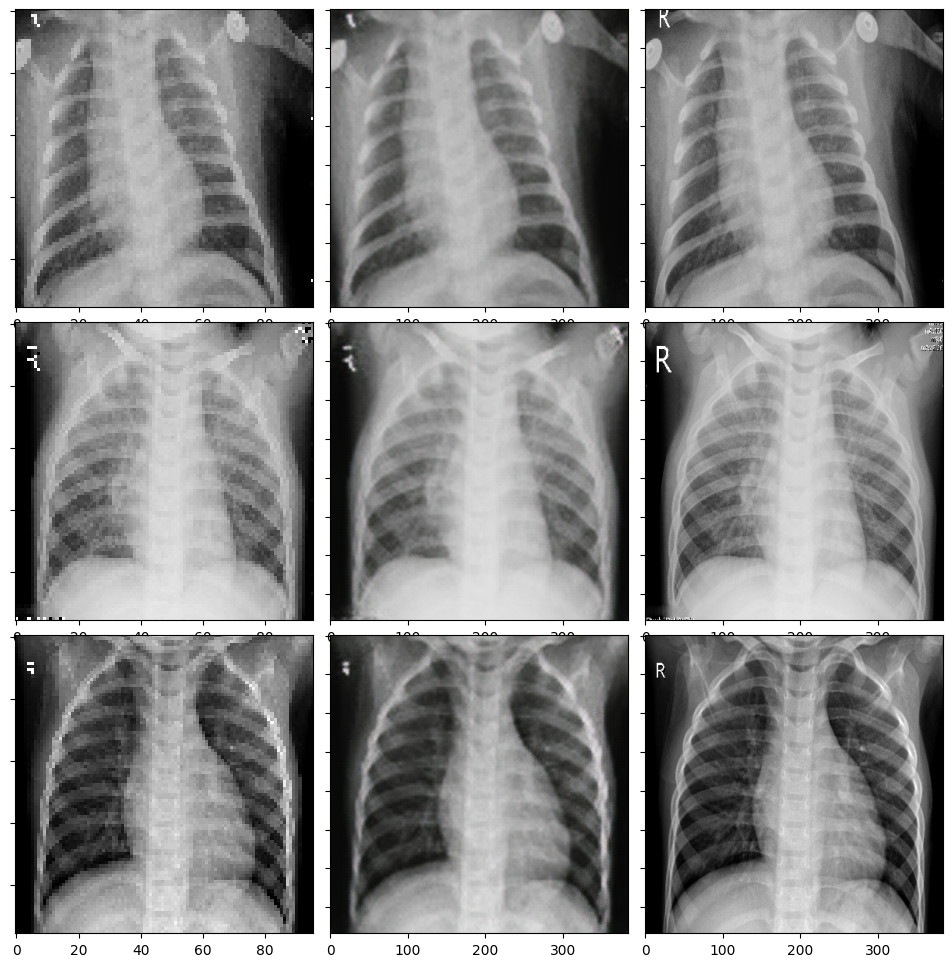

INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


Epoch:  41
ETA: 25.0s d_loss: 1.322355, g_loss: 0.016417, mse_loss: 0.004248, g_gan_loss: 0.001458, vgg_loss: 0.010711, psnr: 33.046803, ssim: 0.757716
Epoch:  42
ETA: 25.0s d_loss: 1.322610, g_loss: 0.016258, mse_loss: 0.004179, g_gan_loss: 0.001458, vgg_loss: 0.010621, psnr: 33.101974, ssim: 0.759227
Epoch:  43
ETA: 25.0s d_loss: 1.322703, g_loss: 0.016107, mse_loss: 0.004115, g_gan_loss: 0.001457, vgg_loss: 0.010535, psnr: 33.152184, ssim: 0.760563
Epoch:  44
ETA: 25.0s d_loss: 1.323548, g_loss: 0.015964, mse_loss: 0.004054, g_gan_loss: 0.001456, vgg_loss: 0.010454, psnr: 33.196228, ssim: 0.761682
Epoch:  45
ETA: 25.0s d_loss: 1.324836, g_loss: 0.015824, mse_loss: 0.003996, g_gan_loss: 0.001454, vgg_loss: 0.010374, psnr: 33.238705, ssim: 0.762774
Epoch:  46
ETA: 25.0s d_loss: 1.325332, g_loss: 0.015689, mse_loss: 0.003940, g_gan_loss: 0.001452, vgg_loss: 0.010296, psnr: 33.281048, ssim: 0.763874
Epoch:  47
ETA: 25.0s d_loss: 1.325362, g_loss: 0.015560, mse_loss: 0.003886, g_gan_loss

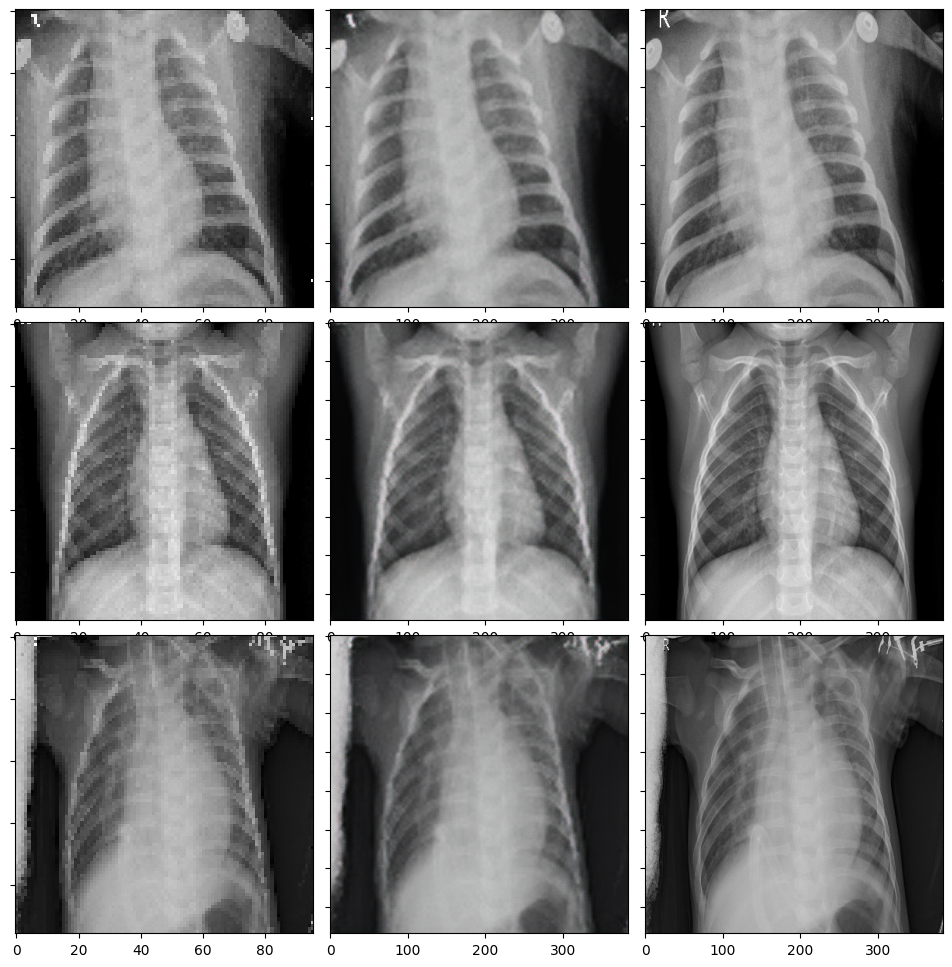

INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


Epoch:  61
ETA: 25.0s d_loss: 1.324291, g_loss: 0.014147, mse_loss: 0.003309, g_gan_loss: 0.001463, vgg_loss: 0.009376, psnr: 33.783951, ssim: 0.777366
Epoch:  62
ETA: 25.0s d_loss: 1.323611, g_loss: 0.014074, mse_loss: 0.003278, g_gan_loss: 0.001465, vgg_loss: 0.009331, psnr: 33.805614, ssim: 0.777920
Epoch:  63
ETA: 25.0s d_loss: 1.323957, g_loss: 0.013999, mse_loss: 0.003248, g_gan_loss: 0.001465, vgg_loss: 0.009286, psnr: 33.827919, ssim: 0.778503
Epoch:  64
ETA: 25.0s d_loss: 1.323514, g_loss: 0.013922, mse_loss: 0.003218, g_gan_loss: 0.001465, vgg_loss: 0.009239, psnr: 33.853886, ssim: 0.779201
Epoch:  65
ETA: 25.0s d_loss: 1.322298, g_loss: 0.013846, mse_loss: 0.003188, g_gan_loss: 0.001467, vgg_loss: 0.009192, psnr: 33.880814, ssim: 0.779942
Epoch:  66
ETA: 25.0s d_loss: 1.321565, g_loss: 0.013778, mse_loss: 0.003160, g_gan_loss: 0.001470, vgg_loss: 0.009148, psnr: 33.902931, ssim: 0.780538
Epoch:  67
ETA: 25.0s d_loss: 1.322077, g_loss: 0.013708, mse_loss: 0.003133, g_gan_loss

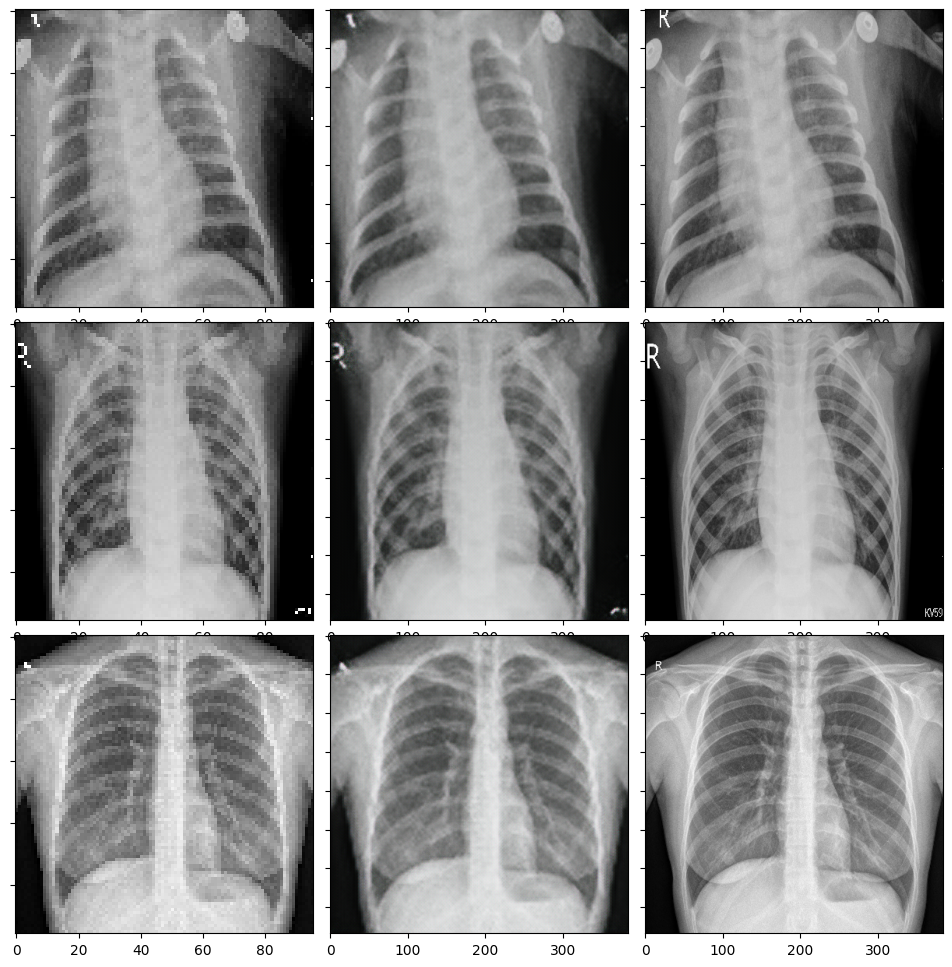

INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


Epoch:  81
ETA: 25.0s d_loss: 1.317990, g_loss: 0.012863, mse_loss: 0.002812, g_gan_loss: 0.001482, vgg_loss: 0.008569, psnr: 34.219234, ssim: 0.788894
Epoch:  82
ETA: 25.0s d_loss: 1.318350, g_loss: 0.012814, mse_loss: 0.002793, g_gan_loss: 0.001483, vgg_loss: 0.008537, psnr: 34.234882, ssim: 0.789302
Epoch:  83
ETA: 25.0s d_loss: 1.318604, g_loss: 0.012764, mse_loss: 0.002775, g_gan_loss: 0.001484, vgg_loss: 0.008504, psnr: 34.251480, ssim: 0.789762
Epoch:  84
ETA: 25.0s d_loss: 1.319022, g_loss: 0.012715, mse_loss: 0.002757, g_gan_loss: 0.001485, vgg_loss: 0.008473, psnr: 34.267605, ssim: 0.790187
Epoch:  85
ETA: 25.0s d_loss: 1.319458, g_loss: 0.012665, mse_loss: 0.002740, g_gan_loss: 0.001484, vgg_loss: 0.008442, psnr: 34.283806, ssim: 0.790614
Epoch:  86
ETA: 25.0s d_loss: 1.319347, g_loss: 0.012615, mse_loss: 0.002722, g_gan_loss: 0.001484, vgg_loss: 0.008410, psnr: 34.301243, ssim: 0.791080
Epoch:  87
ETA: 25.0s d_loss: 1.318977, g_loss: 0.012567, mse_loss: 0.002705, g_gan_loss

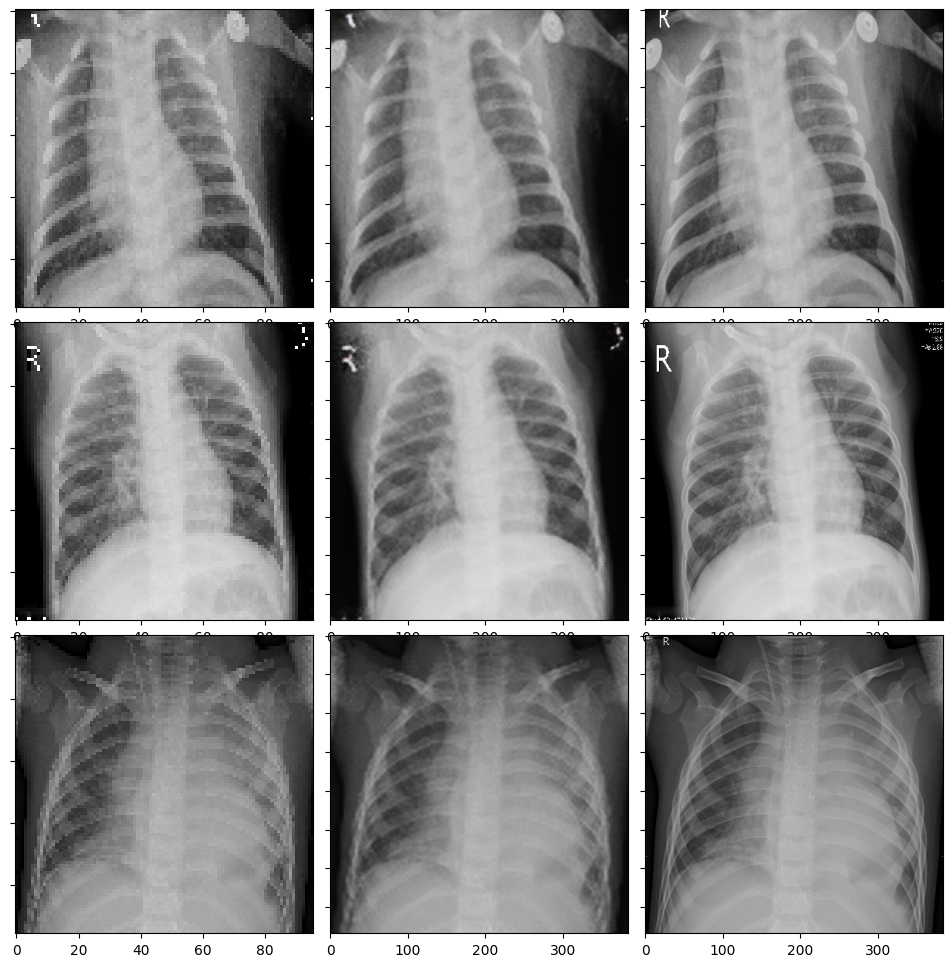

INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/gen/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


INFO:tensorflow:Assets written to: /kaggle/working/disc/assets


In [49]:
with strategy.scope():
    metric_names = ['d_loss', 'g_loss', 'mse_loss', 'g_gan_loss', 'vgg_loss', 'psnr', 'ssim']

    for epoch in tf.range(100):
        start_time = time.time()
        loss= distributed_train_epoch(dataset)
        print("Epoch: ", epoch.numpy()+1)
        print(f"ETA: {np.round(time.time() - start_time)}s {', '.join([f'{metric_name}: {value:.6f}' for metric_name, value in zip(metric_names, loss.numpy())])}")
        if (epoch + 1)%20==0:
            distributed_test_epoch(g, val_dataset, img_convert = True)